### **Załadowanie bibliotek**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Wczytanie danych**

In [2]:
dane = pd.read_csv('dane.csv')

/tmp/ipykernel_1453/3373834769.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dane = pd.read_csv('/content/drive/MyDrive/dane magisterka/dane.csv')


In [3]:
print(dane.shape)
dane.head()

(538471, 24)


,Id,Issue Date,Closing Date,Listing Date,Country,Loan Originator,Mintos Risk Score,Loan Type,Loan Rate Percent,Term,...,Buyback reason,Initial Loan Amount,Remaining Loan Amount,Available for investments,Currency,Buyback,Extendable schedule,Loan Originator Status,In Recovery,ISIN
0,50333604-01,2022-05-28 00:00:00,2023-09-29 00:00:00,2022-05-30 15:39:08,Latvia,Banknote,8.6,Personal Loan,14.5,16,...,Agreement amendment,677.98,0.0,0.0,EUR,Yes,No,Active,No,LVX000000Y74
1,50336144-01,2021-08-06 00:00:00,2026-11-08 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,54,...,Early repayment,5000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0
2,50336154-01,2021-08-19 00:00:00,2026-10-22 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,54,...,Early repayment,5000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0
3,50336155-01,2021-08-19 00:00:00,2026-12-21 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,56,...,Early repayment,4350.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0
4,50336157-01,2021-09-01 00:00:00,2026-08-06 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,50,...,Early repayment,4000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0


### **Zakodowanie zmiennej zależnej 'Ocena'**

In [4]:
dane['Ocena'] = np.nan

In [5]:
dane.loc[dane['Loan Status'] == 'Finished as scheduled', 'Ocena'] = 'dobra'
dane.loc[(dane['Loan Status'] == 'Finished prematurely') & (dane['Buyback reason'] == 'Early repayment'), 'Ocena'] = 'dobra'
dane.loc[(dane['Loan Status'] == 'Finished prematurely') & (dane['Buyback reason'] != 'Early repayment'), 'Ocena'] = 'problematyczna'

/tmp/ipykernel_1453/1911290505.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'dobra' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dane.loc[dane['Loan Status'] == 'Finished as scheduled', 'Ocena'] = 'dobra'


In [6]:
print(dane.shape)
dane.head()

(538471, 25)


,Id,Issue Date,Closing Date,Listing Date,Country,Loan Originator,Mintos Risk Score,Loan Type,Loan Rate Percent,Term,...,Initial Loan Amount,Remaining Loan Amount,Available for investments,Currency,Buyback,Extendable schedule,Loan Originator Status,In Recovery,ISIN,Ocena
0,50333604-01,2022-05-28 00:00:00,2023-09-29 00:00:00,2022-05-30 15:39:08,Latvia,Banknote,8.6,Personal Loan,14.5,16,...,677.98,0.0,0.0,EUR,Yes,No,Active,No,LVX000000Y74,problematyczna
1,50336144-01,2021-08-06 00:00:00,2026-11-08 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,54,...,5000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0,dobra
2,50336154-01,2021-08-19 00:00:00,2026-10-22 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,54,...,5000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0,dobra
3,50336155-01,2021-08-19 00:00:00,2026-12-21 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,56,...,4350.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0,dobra
4,50336157-01,2021-09-01 00:00:00,2026-08-06 00:00:00,2022-05-30 12:34:31,Lithuania,Placet,8.0,Personal Loan,10.0,50,...,4000.00,0.0,0.0,EUR,Yes,Yes,Active,No,LVX000000VD0,dobra


### **Przyjrzenie się zmiennym 'Issue Date' i 'Closing Date'**

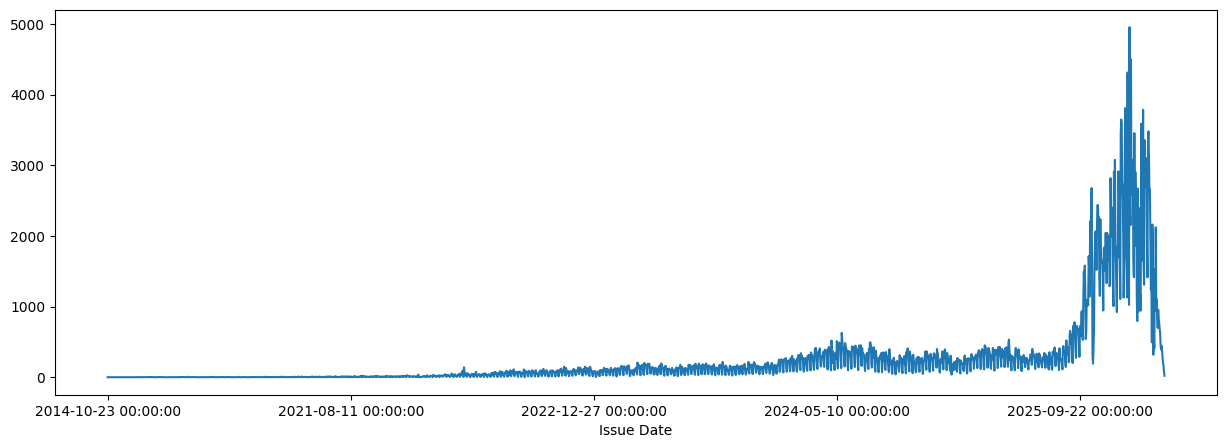

In [7]:
plt.figure(figsize=(15, 5))
dane['Issue Date'].value_counts().sort_index().plot()
plt.show()

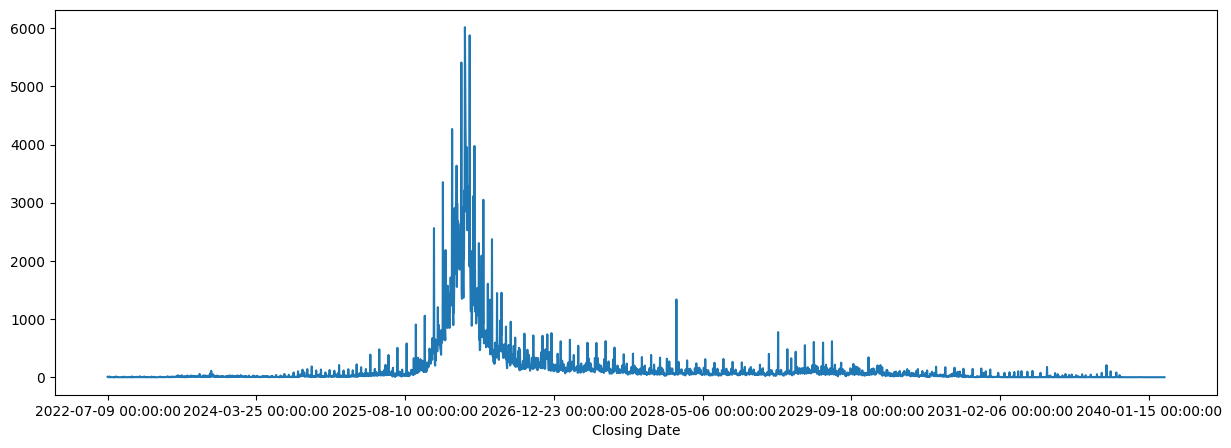

In [8]:
plt.figure(figsize=(15, 5))
dane['Closing Date'].value_counts().sort_index().plot()
plt.show()

### **Ograniczenie danych czasowo wg zmiennej 'Issue Date'**

In [9]:
dane = dane[(dane['Issue Date'] >= '2023-01-01') & (dane['Issue Date'] <= '2025-09-30')]

In [7]:
print(dane.shape)

(214903, 25)


### **Przegląd zmiennych**

In [10]:
dane['Remaining Loan Amount'].value_counts()

,count
Remaining Loan Amount,
0.00,214798
0.01,100
0.02,5


In [11]:
dane = dane[dane['Remaining Loan Amount'] == 0]

In [12]:
dane['Available for investments'].value_counts()

,count
Available for investments,
0.0,214798


In [13]:
dane['Loan Originator Status'].value_counts()

,count
Loan Originator Status,
Active,214798


In [14]:
dane['In Recovery'].value_counts()

,count
In Recovery,
No,214798


In [15]:
dane['Buyback'].value_counts()

,count
Buyback,
Yes,214798


In [16]:
dane['Extendable schedule'].value_counts()

,count
Extendable schedule,
Yes,138271
No,76527


In [17]:
dane['Collateral'].value_counts()

,count
Collateral,
No,205573
Yes,9225


In [18]:
dane['Initial LTV'].value_counts()

,count
Initial LTV,
0,205573
94,2793
100,2112
91,506
92,499
...,...
3,1
129,1
125,1


In [ ]:
dane['LTV'].value_counts()

,count
LTV,
0,214798


**Usunięcie zmiennych:**
*   Id
*   ISIN
*   Issue Date
*   Listing Date
*   Closing Date
*   In recovery
*   Remaining Loan Amount
*   Available for Investments
*   Loan Originator Status
*   Buyback
*   LTV



In [19]:
dane = dane.drop(columns=['Id', 'ISIN', 'Issue Date', 'Listing Date', 'Closing Date', 'In Recovery',
                          'Remaining Loan Amount', 'Available for investments', 'Loan Originator Status', 'Buyback', 'LTV'])

In [12]:
print(dane.shape)
dane.head()

(214798, 14)


,Country,Loan Originator,Mintos Risk Score,Loan Type,Loan Rate Percent,Term,Collateral,Initial LTV,Loan Status,Buyback reason,Initial Loan Amount,Currency,Extendable schedule,Ocena
7809,Kazakhstan,IDF Eurasia,6.6,Personal Loan,22.0,48,No,0,Finished prematurely,Buyback,300000.0,KZT,Yes,problematyczna
7810,Kazakhstan,IDF Eurasia,6.6,Personal Loan,22.0,48,No,0,Finished prematurely,Buyback,345000.0,KZT,Yes,problematyczna
7811,Kazakhstan,IDF Eurasia,6.6,Personal Loan,22.0,36,No,0,Finished prematurely,Buyback,250000.0,KZT,Yes,problematyczna
7813,Kazakhstan,IDF Eurasia,6.6,Personal Loan,22.0,48,No,0,Finished prematurely,Buyback,322000.0,KZT,Yes,problematyczna
7814,Kazakhstan,IDF Eurasia,6.6,Personal Loan,22.0,36,No,0,Finished prematurely,Buyback,275000.0,KZT,Yes,problematyczna


In [20]:
dane = dane[['Ocena', 'Initial Loan Amount', 'Loan Rate Percent', 'Term', 'Currency', 'Country', 'Loan Originator', 'Loan Type', 'Loan Status', 'Buyback reason', 'Mintos Risk Score', 'Collateral', 'Initial LTV', 'Extendable schedule' ]]

In [21]:
dane.dtypes

,0
Ocena,object
Initial Loan Amount,float64
Loan Rate Percent,float64
Term,int64
Currency,object
Country,object
Loan Originator,object
Loan Type,object
Loan Status,object
Buyback reason,object


In [ ]:
dane['Mintos Risk Score'].value_counts()

,count
Mintos Risk Score,
6.6,41080
9.1,26275
6.6,18204
8.6,15993
7.8,11124
7.7,10750
7.3,7777
8.6,7449
5.6,6962


In [22]:
dane = dane[dane['Mintos Risk Score'] != 'SW']

In [16]:
print(dane.shape)

(213522, 14)


In [17]:
dane['Mintos Risk Score'] = dane['Mintos Risk Score'].astype(float)

**Sprawdzenie braków danych**

In [18]:
dane.isnull().sum()

,0
Ocena,0
Initial Loan Amount,0
Loan Rate Percent,0
Term,0
Currency,0
Country,0
Loan Originator,0
Loan Type,315
Loan Status,0
Buyback reason,0


In [ ]:
dane['Loan Type'].value_counts()

,count
Loan Type,
Personal Loan,195408
Car Loan,8512
Short-Term Loan,7063
Business Loan,1304
Pawnbroking Loan,695
Mortgage Loan,224
Agricultural Loan,1


In [19]:
dane = dane[dane['Loan Type'] != 'Agricultural Loan']

In [20]:
dane['Loan Type'].isnull().sum()

np.int64(315)

In [21]:
dane = dane.dropna()

In [22]:
dane['Buyback reason'].value_counts()

,count
Buyback reason,
Buyback,81727
Early repayment,43026
Agreement amendment,39565
-,17428
Other,15705
Agreement termination,15072
Agreement prolongation,683


In [24]:
dane['Ocena'].value_counts()

,count
Ocena,
problematyczna,152752
dobra,60454


In [1]:
dane['Ocena'].value_counts(normalize=True) * 100

NameError: name 'dane' is not defined

In [ ]:
dane.to_csv("dane_przygotowane.csv", decimal = ',', sep = ';', index=False)